#Adivina mi Dibujo Proyecto Final IA
Entrenamiento de un CNN sobre el dataset Quick, Draw! y exportación a TensorFlow.js.




## 1. Instalar dependencias adicionales

In [1]:
!pip install tensorflowjs -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 64.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-server 2.20.0 requires packaging>=22.0, but you have packaging 20.9 which is incompatible.
pysal 25.7 requires packaging>=22, but you have packaging 20.9 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 20.9 which is incompatible.
bigquery-magics 0.14.0 requires packaging>=24.2.0, but you have packaging 20.9 which is incompatible.
google-c

## 2. Descargar el dataset

Categorías elegidas: `gato`, `casa`, `sol`, `arbol`, `pez`.



In [2]:
!mkdir -p data
!wget -q -O data/gato.npy   https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/cat.npy
!wget -q -O data/casa.npy https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/house.npy
!wget -q -O data/sol.npy   https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/sun.npy
!wget -q -O data/arbol.npy  https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/tree.npy
!wget -q -O data/pez.npy  https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/fish.npy
!ls -lh data/

total 502M
-rw-r--r-- 1 root root 109M May 18  2017 arbol.npy
-rw-r--r-- 1 root root 102M May 18  2017 casa.npy
-rw-r--r-- 1 root root  93M May 18  2017 gato.npy
-rw-r--r-- 1 root root 101M May 18  2017 pez.npy
-rw-r--r-- 1 root root 101M May 18  2017 sol.npy


## 3. Configuración y carga de datos

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

CATEGORIES = ["gato", "casa", "sol", "arbol", "pez"]
DATA_DIR = "data"
SAMPLES_PER_CLASS = 4000
IMG_SIZE = 28

def load_data():
    X, y = [], []
    for idx, category in enumerate(CATEGORIES):
        path = os.path.join(DATA_DIR, f"{category}.npy")
        data = np.load(path)
        np.random.shuffle(data)
        data = data[:SAMPLES_PER_CLASS]
        X.append(data)
        y.append(np.full(len(data), idx))
        print(f"  {category}: {len(data)} muestras cargadas")
    X = np.concatenate(X, axis=0).astype("float32") / 255.0
    y = np.concatenate(y, axis=0)
    X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    return X, y

print("Cargando datos...")
X, y = load_data()
print(f"Total: {X.shape[0]} imagenes, {len(CATEGORIES)} categorias")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

Cargando datos...
  gato: 4000 muestras cargadas
  casa: 4000 muestras cargadas
  sol: 4000 muestras cargadas
  arbol: 4000 muestras cargadas
  pez: 4000 muestras cargadas
Total: 20000 imagenes, 5 categorias


## 4. Definir el modelo CNN

In [4]:
model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(len(CATEGORIES), activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,925 (1.75 MB)

 Trainable params: 457,925 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento

In [5]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
)

Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8291 - loss: 0.5012 - val_accuracy: 0.9230 - val_loss: 0.2339
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9321 - loss: 0.2160 - val_accuracy: 0.9480 - val_loss: 0.1654
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9489 - loss: 0.1614 - val_accuracy: 0.9593 - val_loss: 0.1440
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9568 - loss: 0.1333 - val_accuracy: 0.9570 - val_loss: 0.1423
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9628 - loss: 0.1165 - val_accuracy: 0.9620 - val_loss: 0.1247
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9680 - loss: 0.0996 - val_accuracy: 0.9643 - val_loss: 0.1246
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9706 - loss: 0.0880 - val_accuracy: 0.9663 - val_loss: 0.1220
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9760 - loss: 0.0731 - val_accuracy: 

## 6. Evaluación resultados para el informe

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9597 - loss: 0.1418

Accuracy en test: 0.9597
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Reporte de clasificacion:
              precision    recall  f1-score   support

        gato       0.94      0.93      0.93       600
        casa       0.98      0.97      0.97       600
         sol       0.96      0.97      0.96       600
       arbol       0.98      0.96      0.97       600
         pez       0.94      0.97      0.96       600

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000



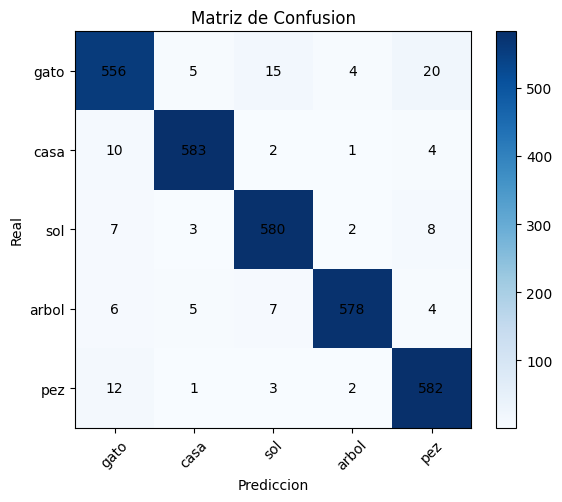

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nAccuracy en test: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de Confusion")
plt.colorbar()
plt.xticks(range(len(CATEGORIES)), CATEGORIES, rotation=45)
plt.yticks(range(len(CATEGORIES)), CATEGORIES)
for i in range(len(CATEGORIES)):
    for j in range(len(CATEGORIES)):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig("matriz_confusion.png")
plt.show()

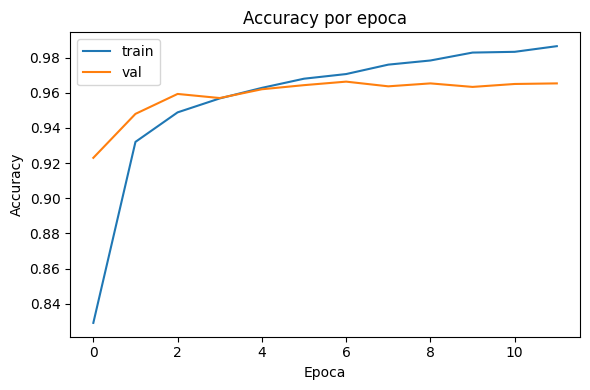

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy por epoca")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("curva_accuracy.png")
plt.show()

In [34]:
from ipycanvas import Canvas
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import numpy as np

CANVAS_SIZE = 280

canvas = Canvas(width=CANVAS_SIZE, height=CANVAS_SIZE, sync_image_data=True)
canvas.fill_style = "black"
canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)
canvas.stroke_style = "white"
canvas.line_width = 18

state = {"drawing": False, "last_x": None, "last_y": None, "move_count": 0}
output_html = widgets.HTML(value="<b>Dibuja algo con el mouse dentro del cuadro negro...</b>")

def predict_and_show():
    arr = canvas.get_image_data()          # HxWx4 (RGBA)
    gray = arr[:, :, 0]                     # canal rojo = intensidad (blanco/negro)
    img = Image.fromarray(gray).resize((28, 28))
    x = np.array(img).astype("float32") / 255.0
    x = x.reshape(1, 28, 28, 1)
    probs = model.predict(x, verbose=0)[0]
    ranked = sorted(zip(CATEGORIES, probs), key=lambda p: -p[1])[:3]
    html = "<br>".join(
        f"<b>{c}</b>: {p*100:.1f}%" for c, p in ranked
    )
    output_html.value = html

def on_mouse_down(x, y):
    state["drawing"] = True
    state["last_x"], state["last_y"] = x, y

def on_mouse_move(x, y):
    if not state["drawing"]:
        return
    canvas.stroke_line(state["last_x"], state["last_y"], x, y)
    state["last_x"], state["last_y"] = x, y
    state["move_count"] += 1
    # predice cada pocos movimientos, no en cada pixel, para que no se sienta lento
    if state["move_count"] % 8 == 0:
        predict_and_show()

def on_mouse_up(x, y):
    state["drawing"] = False
    predict_and_show()  # una última predicción al soltar el trazo

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

clear_button = widgets.Button(description="Limpiar")

def on_clear(b):
    canvas.fill_style = "black"
    canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)
    output_html.value = "<b>Dibuja algo con el mouse dentro del cuadro negro...</b>"

clear_button.on_click(on_clear)

display(widgets.VBox([canvas, clear_button, output_html]))

## 7. Guardar y convertir el modelo para la app web

In [8]:
model.save("modelo_dibujo.h5")
print("Modelo guardado como modelo_dibujo.h5")

Modelo guardado como modelo_dibujo.h5


In [11]:
import numpy as np
np.object = object
np.bool = bool
np.int = int
np.float = float
np.complex = complex

In [14]:
!pip install tensorflow-estimator -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 19.2 MB/s eta 0:00:00


In [18]:
!pip install ipycanvas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.0/143.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 13.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflowjs 3.18.0 requires packaging~=20.9, but you have packaging 26.3 which is incompatible.


In [24]:
from google.colab import output
output.enable_custom_widget_manager()

In [20]:
model.save("modelo_dibujo.h5")
from google.colab import files
files.download("modelo_dibujo.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
from google.colab import files

files.download('modelo_dibujo.h5')
files.download('matriz_confusion.png')
files.download('curva_accuracy.png')

!zip -r model_tfjs.zip model_tfjs
files.download('model_tfjs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

	zip warning: name not matched: model_tfjs

zip error: Nothing to do! (try: zip -r model_tfjs.zip . -i model_tfjs)


FileNotFoundError: Cannot find file: model_tfjs.zip